## Set up Gurobipy
---

In [1]:
# First you can check, whether the required packages are already installed
# (if not, you'll receive a warning)
%pip show gurobipy
%pip show matplotlib
%pip show numpy
%pip show pandas

Name: gurobipy
Version: 12.0.3
Summary: Python interface to Gurobi
Home-page: https://www.gurobi.com
Author: Gurobi Optimization, LLC
Author-email: 
License: Proprietary
Location: c:\Users\knope\AppData\Local\Programs\Python\Python312\Lib\site-packages
Requires: 
Required-by: 
Note: you may need to restart the kernel to use updated packages.
Name: matplotlib
Version: 3.10.7
Summary: Python plotting package
Home-page: https://matplotlib.org
Author: John D. Hunter, Michael Droettboom
Author-email: Unknown <matplotlib-users@python.org>
License: License agreement for matplotlib versions 1.3.0 and later

 1. This LICENSE AGREEMENT is between the Matplotlib Development Team
 ("MDT"), and the Individual or Organization ("Licensee") accessing and
 otherwise using matplotlib software in source or binary form and its
 associated documentation.

 2. Subject to the terms and conditions of this License Agreement, MDT
 hereby grants Licensee a nonexclusive, royalty-free, world-wide license
 to repro

In [2]:
#%pip install gurobipy
#%pip install matplotlib
#%pip install numpy
#%pip install pandas

Import them into this notebook

In [3]:
import gurobipy as gp 
from gurobipy import GRB
from gurobipy import *  # imports everything from gurobipy without alias
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## SALBP-2 model formulation
-----------------------------------------

When it comes to the "Simple Assembly Line Balancing Problem no. 2" there is a number of N operations with precedence relations to be performed on a fixed number of M stations. 
The operations are to be distributed among the stations in such a way that the cycle time is minimized. A simple result is illustrated in this precedence graph including station assignments.

<img src="pics/header2.png" alt="Precedence graph" width="700">

### Objective function:

 0) The goal of the model is to minimize the cycle time:   $ \hspace{31mm} min \quad z = C $

### Constraints:

1) Assignment of  every  operation  only once: $\hspace{45mm} \sum_{k=1}^MS_{ik}=1  \hspace{39mm} \forall i=1,...,N $ 

2) Complying with the precedence relations: $\hspace{45mm} \sum_{k=1}^MS_{ik}\cdot k \leq \sum_{k=1}^MS_{jk}\cdot k \hspace{13mm} 
\forall(i,j) \in P$

3) Complying with the cycle time: $\hspace{63mm} \sum_{i=1}^NS_{ik} \cdot t_i \leq C \hspace{33mm} \forall k=1,...,M $

4) Binary decision variable: $\hspace{74mm} S_{ik} \in \{0,1\} \hspace{41mm} \forall i=1,...,N;k=1,...,M $

5) Non-negativity constraint: $\hspace{72mm} C \geq0$

---

#### Indices and sets
$i,j\in(1,..,N) \hspace{15mm}$  operations                      

$k\in(1,..,M) \hspace{17mm}$ stations                         

$(i,j)\in P \hspace{26mm}$ set of precedence relations     

#### Parameters
$t_i \hspace{40mm}$  Processing time of operation i 

#### Decision variables
$S_{ik} \hspace{38mm}$  Binary variable             

$C \hspace{41mm}$  Cycle time 

------------------------------------------------------------

### Create the model.
---

Initialize the model m with Gurobi as optimizer.

In [4]:
# Model
m = gp.Model("MILP")


# Surpress Output
m.setParam("OutputFlag", 0)
m.setParam("MIPgap", 0)

Set parameter Username
Set parameter LicenseID to value 2725801
Academic license - for non-commercial use only - expires 2026-10-21


### Case study data:
---

#### Number of stations: 6 

#### Operations:
| Operation | processing time| direct predecessors
|:-----------|:----------------|:------------------|
| 1 | 5.5 |   |  
| 2 | 7.4 |   | 
| 3 | 1.3 | 1   | 
| 4 | 9 | 1, 2   | 
| 5 | 2.6 | 3  | 
| 6 | 4.6 | 4, 7  | 
| 7 | 8 | 2  | 
| 8 | 4.5 | 5, 6  | 
| 9 | 3 | 7, 6  | 


### Sets and parameters
---

Insert the parameters: Operations i, Stations k, N, M and the PrecRelations as arrays.

In [5]:
Operations = [1,2,3,4,5,6,7,8,9]
Stations = [1,2,3,4]

N = len(Operations)
M = len(Stations)

PrecRelations = [ [1, 2], [1, 5], [3, 4], [3, 5], [3, 7], [5, 6], [2, 8], [4, 8], [6, 8], [7, 8], [8, 9] ]

Insert the times needed for the single operations $t_i$ as an array.

In [6]:
t = [5.2, 2.8, 3, 8.3, 6.7, 3.5, 7, 2, 1]

### Decision variables
---

Define the decision variables including the non-negativity and binary constraints:

**4) Binary decision variable**: 
The binary decision variable $S_{ik}$ is 1 if an operation i is assigned to station k, otherwise 0.

In [7]:
S = m.addVars(N, M, vtype=GRB.BINARY, name="S");

**5)  Non-negativity constraint**:  The cycle time C can't be negative.

In [8]:
C = m.addVar(lb=0, name="C");

**5)  Auxiliary variable to break symmetry**:  Prefer assignment to lower station number in case of multiple solutions

In [9]:
symBreak = m.addVar(lb=0, name="symBreak");

### Objective function 
---

Define the objective value to minimize the cycle time.

Note: You can ignore the additional term "symBreak". We just want to make sure that everyone gets the same results when there is more than one possible solutions. 

*Be careful though! Because of this addition the optimal cycle time differs from the objective value.*

In [10]:
m.setObjective(C + symBreak, GRB.MINIMIZE)

### Constraints
---


**1) Assign every operation only once**: Each operation may be assigned only once. The sum of the number of assignments of each operation across all stations must therefore add up to one. 

$ \qquad \sum_{k=1}^{M} S_{ik} = 1 \hspace{40mm} \forall i=1,...,N$

In [11]:
m.addConstrs((quicksum(S[i, k] for k in range(M)) == 1 for i in range(N)), name="allOperCon");

**2) Complying the precedence relations**: An operation j may only begin when the predecessor operation i has been completed and can therefore not be processed on a station in front of i's processing station.

$ \qquad \sum_{k=1}^{M} S_{ik}\cdot k \leq \sum_{k=1}^{M} S_{jk}\cdot k \hspace{25mm}  \forall (i,j) \in P $

In [12]:
m.addConstrs((quicksum(S[i, k]*k for k in range(M)) <= quicksum(S[j, k]*k for k in range(M))
              for i in range(N) for j in range(N) if [i+1,j+1] in PrecRelations), name="precRelCon");

**3) Complying the cycle time**:
The cycle time must be smaller than the sum of the processing times of all operations carried out on a station k.

$ \qquad  \sum_{i=1}^NS_{ik} \cdot t_i \leq C \hspace{34mm} \forall k=1,...,M $




In [13]:
m.addConstrs((quicksum(S[i, k]*t[i] for i in range(N)) <= C for k in range(M)), name="cycleTimeCon");

**4) Symmetry breaking constraint**

In [14]:
m.addConstr(symBreak >= quicksum(S[i, k]*k*(0.1**(i+1)) for k in range(M) for i in range(N)), name="symBreakCon");

In [15]:
m.addConstr((S[2,1] == 1), name = "NewMachine");

In [16]:
#m.addConstrs((quicksum(S[i, k] for i in range(N)) <= 2 for k in range(M)), name = "TwoOperations");

### Solve and display results
---

Get the whole model m displayed.

In [17]:
m

<gurobi.Model Continuous instance MILP: 0 constrs, 0 vars, Parameter changes: MIPGap=0.0, Username=(user-defined), LicenseID=2725801, OutputFlag=0>

Run the model m.

In [18]:
# Solve
m.optimize()


### Get the results displayed.

Print out the objective value C as well as the termination status and the primal status.

In [19]:
# Print results
if m.status == GRB.OPTIMAL:
    print("Objective value: ", m.objVal)
    print("Cycle Time C: ", C.x)
    print("Solution:")
    for i in range(N):
        for k in range(M):
            if S[i, k].x > 0.5:
                print("Operation ", i+1, " is assigned to station ", k+1)
else:
    print("No solution found")

Objective value:  11.301122333
Cycle Time C:  11.3
Solution:
Operation  1  is assigned to station  1
Operation  2  is assigned to station  1
Operation  3  is assigned to station  2
Operation  4  is assigned to station  2
Operation  5  is assigned to station  3
Operation  6  is assigned to station  3
Operation  7  is assigned to station  4
Operation  8  is assigned to station  4
Operation  9  is assigned to station  4


Now get displayed where each operation is performed, there might be other solutions as well leading to the same objective function value.

Want to add a nice visualization?

In [20]:
S_vals = m.getAttr('x', S)

df_S = (
    pd.Series(S_vals)
      .rename_axis(["N", "M"])
      .reset_index(name="S")
)

df1 = list(range(N))
mapping1 = dict(zip(df1, t))

mapping2 = {0: 1, 1: 2, 2: 3, 3: 4, 4: 5, 5: 6, 6: 7, 7: 8, 8: 9} # Hängt von Operations ab
df_S['N1'] = df_S['N']
df_S["N"] = df_S["N"].map(mapping2)
df_S["N1"] = df_S["N1"].map(mapping1)
df_S["CT"] = df_S.N1*df_S.S
df_SS = df_S.groupby('M')['CT'].sum().reset_index()

In [21]:
rows = []
for i in range(N):
    for k in range(M):
        if S[i, k].x > 0.5:
            rows.append((i, k))

df_alloc = pd.DataFrame(rows, columns=["Operation", "Station"])
df_alloc

df_SS
df_SS.rename(columns={"M":"Station"}, inplace=True)
df_alloc = df_alloc.merge(df_SS, on="Station", how="left")

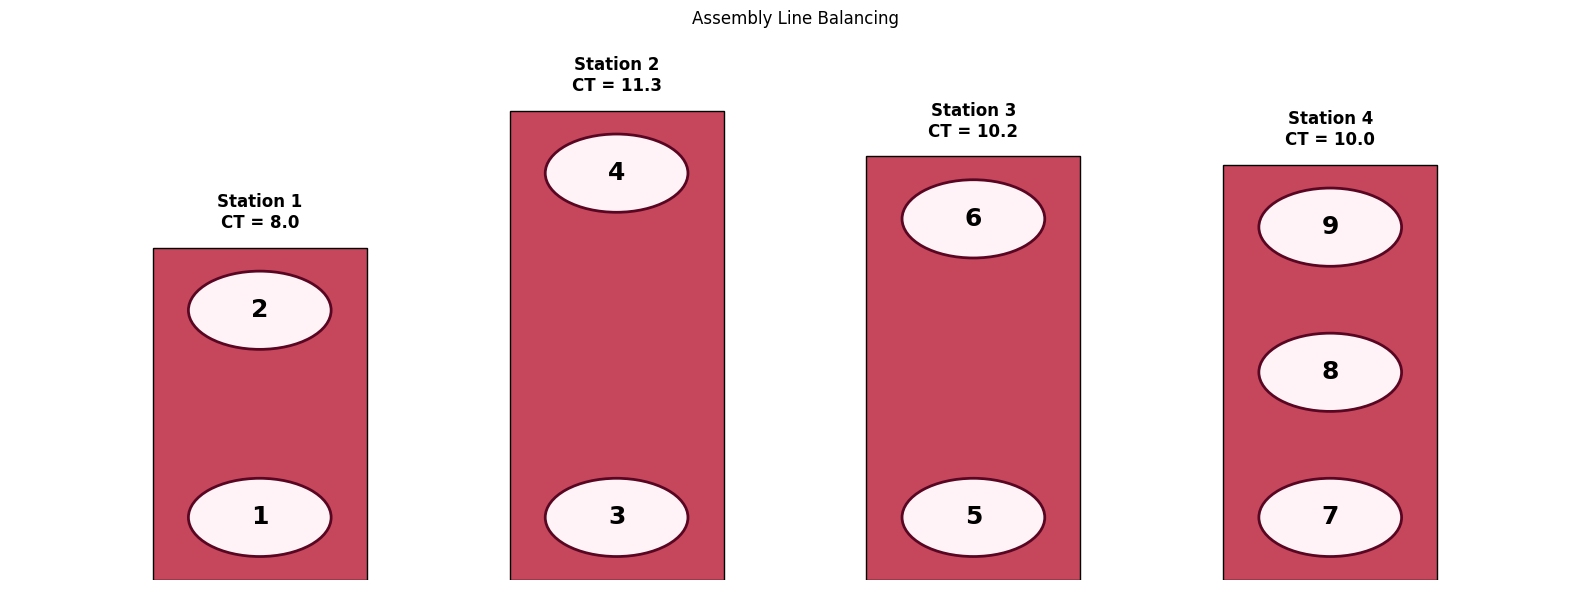

In [22]:
unique_stations = sorted(df_alloc["Station"].unique())
num_stations = len(unique_stations)

fig, ax = plt.subplots(figsize=(16,6))

width = 1.5
spacing = 1.0
radius = 0.5

m_h = 6
max_CT = df_alloc["CT"].max()
scale = m_h / max_CT

for idx, s in enumerate(unique_stations):
    
    x_pos = idx * (width + spacing)

    ct_val = df_alloc[df_alloc["Station"] == s]["CT"].iloc[0]
    col_height = ct_val * scale

    ax.add_patch(plt.Rectangle(
        (x_pos, 0), width, col_height,
        facecolor="#c6475c", edgecolor="black"
    ))

    ax.text(
        x_pos + width/2, col_height + 0.2,
        f"Station {s+1}\nCT = {ct_val:.1f}",
        ha="center", va="bottom",
        fontsize=12, fontweight="bold"
    )

    ops_here = list(df_alloc[df_alloc["Station"] == s]["Operation"])

    if len(ops_here) > 0:
        y_positions = np.linspace(0.8, col_height - 0.8, len(ops_here))
    else:
        y_positions = []

    for op, y in zip(ops_here, y_positions):
        circ = plt.Circle(
            (x_pos + width/2, y),
            radius,
            edgecolor="#590623",
            facecolor="#fff3f7",
            linewidth=2
        )
        ax.add_patch(circ)

        ax.text(
            x_pos + width/2, y,
            str(op+1),
            ha="center", va="center",
            fontsize=18, fontweight="bold"
        )

ax.set_xlim(-1, num_stations * (width + spacing))
ax.set_ylim(0, m_h + 1)
ax.axis("off")

plt.title("Assembly Line Balancing")
plt.tight_layout()
plt.show()
